In [78]:
#CNN AI data
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from scipy.optimize import minimize
from scipy.stats import norm 
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
import random
from random import sample
import wandb

In [79]:
# Load data
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import f1_score
from sklearn import preprocessing
import numpy as np
import matplotlib.pyplot as plt
with open("data (1).pkl", "rb") as f:
    data = pickle.load(f)

x = np.array(data['x'])
y = np.array(data['y'])
y = y[:x.shape[0]]  # Trim y to match x if necessary

# Subsets (optional, not used directly in model training)
ai_data = x[y == 0]
human_data = x[y == 1]

train_data=np.loadtxt("ECG200_TRAIN.txt")
test_data=np.loadtxt("ECG200_TEST.txt")

In [34]:
# Optimised CNN AI data
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Load and preprocess data
with open("data (1).pkl", "rb") as f:
    data = pickle.load(f)

x = np.array(data['x'])
y = np.array(data['y'])[:x.shape[0]]  # Ensure same length

# CNN definition
class CNN1D(nn.Module):
    def __init__(self, input_length, laten=10):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, laten, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(laten, laten, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        self.flatten = nn.Flatten()
        conv_output_length = self._get_conv_output_shape(input_length)
        self.fc1 = nn.Linear(conv_output_length, laten)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(laten, 1)
        self.sigmoid = nn.Sigmoid()

    def _get_conv_output_shape(self, input_length):
        dummy_input = torch.zeros(1, 1, input_length)
        x = self.pool1(torch.relu(self.conv1(dummy_input)))
        x = self.pool2(torch.relu(self.conv2(x)))
        return x.view(1, -1).size(1)

    def forward(self, x):
        x = x.permute(0, 2, 1)  # [batch, channels=1, time]
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return self.sigmoid(x)

# Helper to get sub-interval
def get_sampled_interval(data, center, width):
    start = max(0, center - width // 2)
    end = min(data.shape[1], center + width // 2)
    return start, end

# Train CNN on a specific interval
def train_nn(data, labels, center, width, plot=False):
    start, end = get_sampled_interval(data, center, width)
    interval_length = end - start
    if interval_length < 6:  # Ensure enough input for conv/pool
        return 1.0  # Max error to discourage using this interval

    x = data[:, start:end]
    y = labels.astype(np.float32).reshape(-1, 1)

    scaler = StandardScaler().fit(x)
    x = scaler.transform(x)[:, :, np.newaxis]

    x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)
    x_train = torch.tensor(x_train).float()
    x_test = torch.tensor(x_test).float()
    y_train = torch.tensor(y_train).float()
    y_test = torch.tensor(y_test).float()

    model = CNN1D(input_length=x.shape[1])
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)

    model.train()
    for epoch in range(10):
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(x_test).numpy()
        y_pred = (preds > 0.5).astype(int)
    return 1 - accuracy_score(y_test.numpy(), y_pred)

# Train on full feature window
def train_full_nn(data, labels):
    return train_nn(data, labels, center=data.shape[1] // 2, width=data.shape[1])

# Bayesian Optimisation
interval_width = 10
n_initial = 10
center_bounds = (0, x.shape[1] - 1)
initial_centers = np.random.choice(np.arange(center_bounds[0], center_bounds[1]), size=n_initial, replace=False)
x_sample = initial_centers.reshape(-1, 1)
y_sample = np.array([train_nn(x, y, c, interval_width) for c in initial_centers]).reshape(-1, 1)

# Expected Improvement function
def expected_improvement(X, X_sample, Y_sample, model, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    mu_sample_opt = np.min(Y_sample)
    with np.errstate(divide='warn'):
        imp = mu_sample_opt - mu - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# GP and BO loop
kernel = Matern(nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10)
max_iter = 30

for _ in range(max_iter):
    gp.fit(x_sample, y_sample)
    grid = np.arange(center_bounds[0], center_bounds[1] + 1).reshape(-1, 1)
    tried = set(x_sample.ravel())
    grid = np.array([pt for pt in grid if pt[0] not in tried])
    if len(grid) == 0:
        break
    ei = expected_improvement(grid, x_sample, y_sample, gp)
    best_idx = np.argmax(ei)
    next_point = grid[best_idx][0]
    new_error = train_nn(x, y, next_point, interval_width)
    x_sample = np.vstack((x_sample, [[next_point]]))
    y_sample = np.append(y_sample, [[new_error]])

# Report best interval
best_idx = np.argmin(y_sample)
best_center = int(x_sample[best_idx][0])
best_start, best_end = get_sampled_interval(x, best_center, interval_width)
best_error = float(y_sample[best_idx])
full_model_error = train_full_nn(x, y)

print("Best interval center:", best_center)
print(f"Best interval range:  ({best_start} to {best_end})")
print(f"Best interval error:  {best_error:.4f}")
print(f"Full model error:     {full_model_error:.4f}")


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 5 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Best interval center: 148
Best interval range:  (143 to 153)
Best interval error:  0.3100
Full model error:     0.1225


In [77]:
#optimised CNN ECG Data
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

# Load ECG200 train and test sets
train_data = np.loadtxt("ECG200_TRAIN.txt")
test_data = np.loadtxt("ECG200_TEST.txt")

train_labels = train_data[:, 0]
train_features = train_data[:, 1:]
test_labels = test_data[:, 0]
test_features = test_data[:, 1:]

x = np.vstack((train_features, test_features)).astype(np.float32)
y = ((np.concatenate((train_labels, test_labels)) + 1) / 2).astype(int)


# === Optimised CNN Definition ===
class CNN1D(nn.Module):
    def __init__(self, input_length, laten=10):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, laten, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(laten, laten, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool1d(2)
        self.flatten = nn.Flatten()
        conv_output_length = self._get_conv_output_shape(input_length)
        self.fc1 = nn.Linear(conv_output_length, laten)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(laten, 1)

    def _get_conv_output_shape(self, input_length):
        dummy_input = torch.zeros(1, 1, input_length)
        x = self.pool1(torch.relu(self.conv1(dummy_input)))
        x = self.pool2(torch.relu(self.conv2(x)))
        return x.view(1, -1).size(1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

# === Training on interval ===
def train_nn(data, labels, center, width):
    start = max(0, center - width // 2)
    end = min(data.shape[1], center + width // 2)
    if end - start < 6:  # fail-safe for short intervals
        return 1.0

    x_interval = data[:, start:end]
    y_binary = labels.astype(np.float32).reshape(-1, 1)

    scaler = StandardScaler().fit(x_interval)
    x_scaled = scaler.transform(x_interval)[:, :, np.newaxis]

    x_train, x_test, y_train, y_test = train_test_split(x_scaled, y_binary, test_size=0.2, stratify=y_binary, random_state=42)
    x_train = torch.tensor(x_train).float()
    x_test = torch.tensor(x_test).float()
    y_train = torch.tensor(y_train).float()
    y_test = torch.tensor(y_test).float()

    model = CNN1D(input_length=x_train.shape[1])
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)

    model.train()
    for epoch in range(15):
        for xb, yb in train_loader:
            optimizer.zero_grad()
            output = model(xb)
            loss = criterion(output, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(x_test)).squeeze()
        preds = (probs > 0.5).int().numpy()
    return 1 - accuracy_score(y_test.numpy(), preds)

# === Full window training ===
def train_full_nn(data, labels):
    y_binary = labels.astype(np.float32).reshape(-1, 1)
    scaler = StandardScaler().fit(data)
    x_scaled = scaler.transform(data)[:, :, np.newaxis]

    x_train, x_test, y_train, y_test = train_test_split(x_scaled, y_binary, test_size=0.2, stratify=y_binary, random_state=42)
    x_train = torch.tensor(x_train).float()
    x_test = torch.tensor(x_test).float()
    y_train = torch.tensor(y_train).float()
    y_test = torch.tensor(y_test).float()

    model = CNN1D(input_length=x_train.shape[1])
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)

    model.train()
    for epoch in range(15):
        for xb, yb in train_loader:
            optimizer.zero_grad()
            output = model(xb)
            loss = criterion(output, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(x_test)).squeeze()
        preds = (probs > 0.5).int().numpy()
    return 1 - accuracy_score(y_test.numpy(), preds)


# === Bayesian Optimisation ===
interval_width = 20
n_initial = 10
center_bounds = (0, x.shape[1] - 1)
initial_centers = np.random.choice(np.arange(center_bounds[0], center_bounds[1]), size=n_initial, replace=False)
x_sample = initial_centers.reshape(-1, 1)
y_sample = np.array([train_nn(x, y, c, interval_width) for c in initial_centers]).reshape(-1, 1)

def expected_improvement(X, X_sample, Y_sample, model, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    mu_sample_opt = np.min(Y_sample)
    with np.errstate(divide='warn'):
        imp = mu_sample_opt - mu - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# BO loop
kernel = Matern(nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10)
max_iter = 30

for _ in range(max_iter):
    gp.fit(x_sample, y_sample)
    grid = np.arange(center_bounds[0], center_bounds[1] + 1).reshape(-1, 1)
    tried = set(x_sample.ravel())
    grid = np.array([pt for pt in grid if pt[0] not in tried])
    if len(grid) == 0:
        break

    ei = expected_improvement(grid, x_sample, y_sample, gp)
    best_idx = np.argmax(ei)
    next_point = grid[best_idx][0]
    new_error = train_nn(x, y, next_point, interval_width)
    x_sample = np.vstack((x_sample, [[next_point]]))
    y_sample = np.append(y_sample, [[new_error]])

# === Best result output ===
best_idx = np.argmin(y_sample)
best_center = int(x_sample[best_idx][0])
best_start = max(0, best_center - interval_width // 2)
best_end = min(x.shape[1], best_center + interval_width // 2)
best_error = float(y_sample[best_idx])
full_model_error = train_full_nn(x, y)

print(" Best interval center:", best_center)
print(" Best interval range:  ({} to {})".format(best_start, best_end))
print(" Best interval error:  {:.4f}".format(best_error))
print(" Full model error:     {:.4f}".format(full_model_error))


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 5 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 3 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 4 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_resul

 Best interval center: 26
 Best interval range:  (16 to 36)
 Best interval error:  0.1000
 Full model error:     0.1750


In [26]:
#Parametired width optimised CNN ECG
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

# Load ECG200 dataset
train_data = np.loadtxt("ECG200_TRAIN.txt")
test_data = np.loadtxt("ECG200_TEST.txt")

train_labels = train_data[:, 0]
train_features = train_data[:, 1:]
test_labels = test_data[:, 0]
test_features = test_data[:, 1:]

x = np.vstack((train_features, test_features)).astype(np.float32)
y = ((np.concatenate((train_labels, test_labels)) + 1) / 2).astype(int)

# CNN model
class CNN1D(nn.Module):
    def __init__(self, input_length, laten=10):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, laten, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(laten, laten, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool1d(2)
        self.flatten = nn.Flatten()
        conv_output_length = self._get_conv_output_shape(input_length)
        self.fc1 = nn.Linear(conv_output_length, laten)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(laten, 1)

    def _get_conv_output_shape(self, input_length):
        dummy_input = torch.zeros(1, 1, input_length)
        x = self.pool1(torch.relu(self.conv1(dummy_input)))
        x = self.pool2(torch.relu(self.conv2(x)))
        return x.view(1, -1).size(1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

# Training on interval
def train_nn(data, labels, center, width):
    start = max(0, center - width // 2)
    end = min(data.shape[1], center + width // 2)
    if end - start < 6:
        return 1.0

    x_interval = data[:, start:end]
    y_binary = labels.astype(np.float32).reshape(-1, 1)

    scaler = StandardScaler().fit(x_interval)
    x_scaled = scaler.transform(x_interval)[:, :, np.newaxis]

    x_train, x_test, y_train, y_test = train_test_split(x_scaled, y_binary, test_size=0.2, stratify=y_binary, random_state=42)
    x_train = torch.tensor(x_train).float()
    x_test = torch.tensor(x_test).float()
    y_train = torch.tensor(y_train).float()
    y_test = torch.tensor(y_test).float()

    model = CNN1D(input_length=x_train.shape[1])
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)

    model.train()
    for epoch in range(15):
        for xb, yb in train_loader:
            optimizer.zero_grad()
            output = model(xb)
            loss = criterion(output, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(x_test)).squeeze()
        preds = (probs > 0.5).int().numpy()
    return 1 - accuracy_score(y_test.numpy(), preds)

# Expected improvement
def expected_improvement(X, X_sample, Y_sample, model, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    mu_sample_opt = np.min(Y_sample)
    with np.errstate(divide='warn'):
        imp = mu_sample_opt - mu - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# BO over (center, width)
center_bounds = (0, x.shape[1] - 1)
width_bounds = (6, x.shape[1])  # enforce minimum width of 6

n_initial = 10
initial_samples = np.array([
    [np.random.randint(center_bounds[0], center_bounds[1]),
     np.random.randint(width_bounds[0], width_bounds[1])]
    for _ in range(n_initial)
])

x_sample = initial_samples
y_sample = np.array([train_nn(x, y, c, w) for c, w in x_sample]).reshape(-1, 1)

kernel = Matern(nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10)
max_iter = 30

for _ in range(max_iter):
    gp.fit(x_sample, y_sample)

    candidate_grid = np.array([
        [c, w]
        for c in range(center_bounds[0], center_bounds[1])
        for w in range(width_bounds[0], width_bounds[1])
        if [c, w] not in x_sample.tolist() and
           (c - w // 2 >= 0) and (c + w // 2 <= x.shape[1])
    ])

    if len(candidate_grid) == 0:
        break

    ei = expected_improvement(candidate_grid, x_sample, y_sample, gp)
    best_idx = np.argmax(ei)
    next_c, next_w = candidate_grid[best_idx]

    new_error = train_nn(x, y, next_c, next_w)
    x_sample = np.vstack((x_sample, [[next_c, next_w]]))
    y_sample = np.append(y_sample, [[new_error]])

# Best result
best_idx = np.argmin(y_sample)
best_center, best_width = x_sample[best_idx]
best_start = max(0, best_center - best_width // 2)
best_end = min(x.shape[1], best_center + best_width // 2)
best_error = float(y_sample[best_idx])

print(" Best interval center:", best_center)
print(" Best interval width: ", best_width)
print(" Best interval range:  ({} to {})".format(best_start, best_end))
print(" Best interval error:  {:.4f}".format(best_error))


 Best interval center: 53
 Best interval width:  68
 Best interval range:  (19 to 87)
 Best interval error:  0.1000


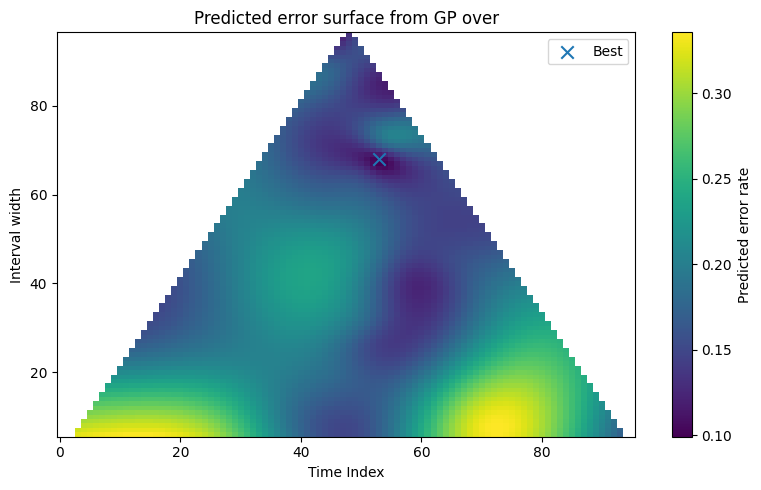

In [27]:
# --- Heat map of predicted error vs (centre, width) --------------------------
import numpy as np
import matplotlib.pyplot as plt

# Refit GP on all sampled points (y_sample can be (n,1), squeeze to (n,))
gp.fit(x_sample, y_sample)

# Build a dense feasible grid of (centre, width)
centres = np.arange(center_bounds[0], center_bounds[1] + 1)
widths  = np.arange(width_bounds[0], width_bounds[1] + 1)

# Pre-allocate heat map with NaNs
heat = np.full((len(widths), len(centres)), np.nan, dtype=float)

grid_points = []
grid_coords = []  # (w_idx, c_idx)
for wi, w in enumerate(widths):
    for ci, c in enumerate(centres):
        # Only keep intervals that fit entirely in the signal
        if (c - w // 2) >= 0 and (c + w // 2) <= x.shape[1]:
            grid_points.append([c, w])
            grid_coords.append((wi, ci))

if len(grid_points) > 0:
    grid_points = np.array(grid_points, dtype=float)
    mu, _ = gp.predict(grid_points, return_std=True)
    # Fill heat map with predictions
    for (wi, ci), m in zip(grid_coords, mu):
        heat[wi, ci] = float(m)

# Plot heat map
plt.figure(figsize=(8, 5))
C, W = np.meshgrid(centres, widths)  # axes reflect actual values
plt.pcolormesh(C, W, heat, shading="auto")
plt.colorbar(label="Predicted error rate")
plt.xlabel("Time Index")
plt.ylabel("Interval width")
plt.title("Predicted error surface from GP over")

# Overlay sampled points and best found
plt.scatter([best_center], [best_width], marker="x", s=80, label="Best")
plt.legend(loc="upper right")

plt.tight_layout()
plt.savefig("bo_width_centre_heatmap.png", dpi=150)
plt.show()

# (Optional) Save the heat map data as CSV (only finite entries)
rows = []
for wi, w in enumerate(widths):
    for ci, c in enumerate(centres):
        val = heat[wi, ci]
        if np.isfinite(val):
            rows.append({"width": int(w), "centre": int(c), "pred_error": float(val)})
import pandas as pd
pd.DataFrame(rows).to_csv("bo_width_centre_heatmap.csv", index=False)


Best interval start: 145
Best interval end:   512
Best width:          367
Best interval error: 0.1075
Full model error:    0.1075


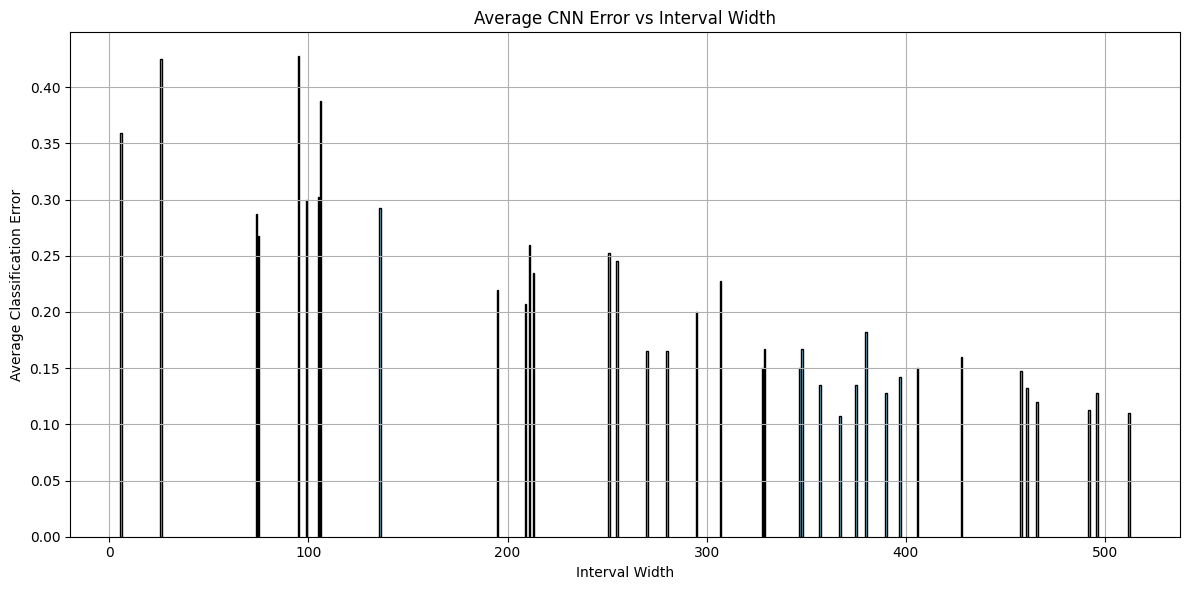

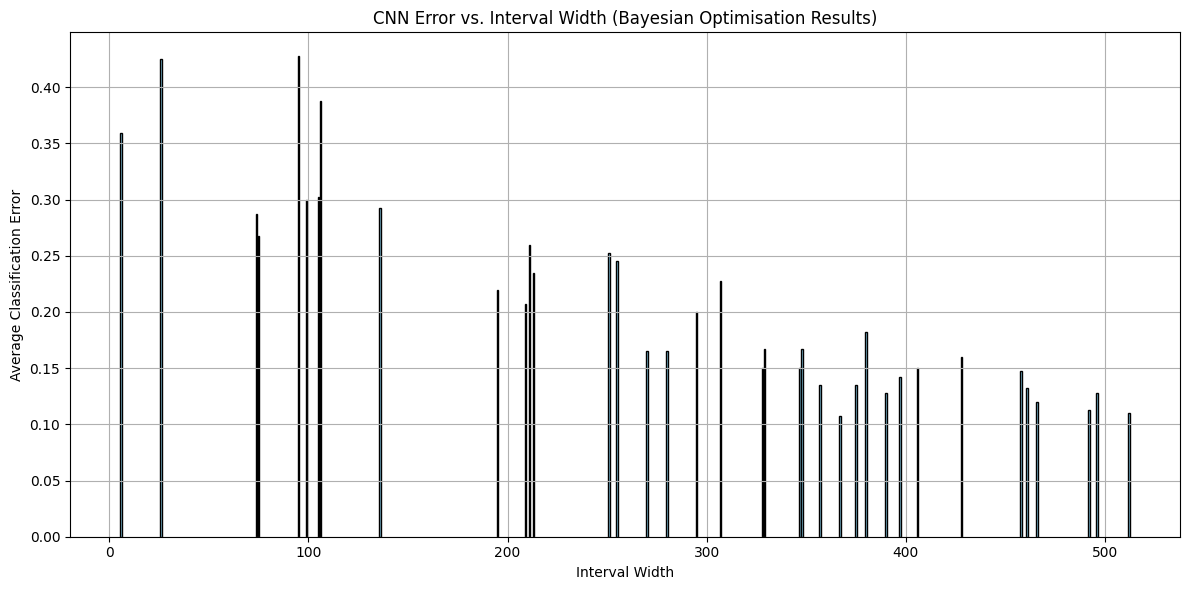

In [20]:
#Parametrised width CNN AI
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# === Load and preprocess data ===
with open("data (1).pkl", "rb") as f:
    data = pickle.load(f)

x = np.array(data['x'])
y = np.array(data['y'])[:x.shape[0]]
signal_length = x.shape[1]

# === CNN definition ===
class CNN1D(nn.Module):
    def __init__(self, input_length, laten=10):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, laten, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(laten, laten, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        self.flatten = nn.Flatten()
        conv_output_length = self._get_conv_output_shape(input_length)
        self.fc1 = nn.Linear(conv_output_length, laten)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(laten, 1)
        self.sigmoid = nn.Sigmoid()

    def _get_conv_output_shape(self, input_length):
        dummy_input = torch.zeros(1, 1, input_length)
        x = self.pool1(torch.relu(self.conv1(dummy_input)))
        x = self.pool2(torch.relu(self.conv2(x)))
        return x.view(1, -1).size(1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.sigmoid(self.fc2(x))

# === Train CNN on interval [start:end] ===
def train_nn(data, labels, start, end):
    if end - start < 6:
        return 1.0

    x_interval = data[:, start:end]
    y_binary = labels.astype(np.float32).reshape(-1, 1)

    scaler = StandardScaler().fit(x_interval)
    x_scaled = scaler.transform(x_interval)[:, :, np.newaxis]

    x_train, x_test, y_train, y_test = train_test_split(x_scaled, y_binary, stratify=y_binary, test_size=0.2, random_state=42)
    x_train = torch.tensor(x_train).float()
    x_test = torch.tensor(x_test).float()
    y_train = torch.tensor(y_train).float()
    y_test = torch.tensor(y_test).float()

    model = CNN1D(input_length=x_train.shape[1])
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)

    model.train()
    for epoch in range(10):
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(x_test).numpy()
        y_pred = (preds > 0.5).astype(int)
    return 1 - accuracy_score(y_test.numpy(), y_pred)

# === Train on full signal ===
def train_full_nn(data, labels):
    return train_nn(data, labels, start=0, end=signal_length)

# === Expected Improvement ===
def expected_improvement(X, X_sample, Y_sample, model, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    mu_sample_opt = np.min(Y_sample)
    with np.errstate(divide='warn'):
        imp = mu_sample_opt - mu - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# === BO over (start, end) pairs ===
min_width = 6
n_initial = 10
initial_samples = []

while len(initial_samples) < n_initial:
    s = np.random.randint(0, signal_length - min_width)
    e = np.random.randint(s + min_width, signal_length + 1)
    initial_samples.append([s, e])

x_sample = np.array(initial_samples)
y_sample = np.array([train_nn(x, y, s, e) for s, e in x_sample]).reshape(-1, 1)

kernel = Matern(nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10)
max_iter = 30

for _ in range(max_iter):
    gp.fit(x_sample, y_sample)

    candidate_grid = np.array([
        [s, e]
        for s in range(0, signal_length - min_width)
        for e in range(s + min_width, signal_length + 1)
        if [s, e] not in x_sample.tolist()
    ])

    if len(candidate_grid) == 0:
        break

    ei = expected_improvement(candidate_grid, x_sample, y_sample, gp)
    best_idx = np.argmax(ei)
    next_s, next_e = candidate_grid[best_idx]

    new_error = train_nn(x, y, next_s, next_e)
    x_sample = np.vstack((x_sample, [[next_s, next_e]]))
    y_sample = np.append(y_sample, [[new_error]])

# === Report best interval ===
best_idx = np.argmin(y_sample)
best_start, best_end = x_sample[best_idx]
best_error = float(y_sample[best_idx])
full_model_error = train_full_nn(x, y)

print("Best interval start:", best_start)
print("Best interval end:  ", best_end)
print("Best width:         ", best_end - best_start)
print("Best interval error:", round(best_error, 4))
print("Full model error:   ", round(full_model_error, 4))

import numpy as np
import matplotlib.pyplot as plt

# Extract widths and errors from sampled (start, end) intervals
x_sample = np.array(x_sample)
y_sample = np.array(y_sample).flatten()
widths = x_sample[:, 1] - x_sample[:, 0]

# Create bins of widths and average errors per width
unique_widths = np.unique(widths)
avg_errors = [np.mean(y_sample[widths == w]) for w in unique_widths]

# Plot heatmap-style bar plot
plt.figure(figsize=(12, 6))
plt.bar(unique_widths, avg_errors, color='skyblue', edgecolor='black')
plt.xlabel("Interval Width")
plt.ylabel("Average Classification Error")
plt.title("Average CNN Error vs Interval Width")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Plot: CNN Error vs Interval Width ===
import matplotlib.pyplot as plt
import numpy as np

# Recalculate widths and error values
x_sample = np.array(x_sample)
y_sample = np.array(y_sample).flatten()
widths = x_sample[:, 1] - x_sample[:, 0]

# Group by unique widths
unique_widths = np.unique(widths)
avg_errors = [np.mean(y_sample[widths == w]) for w in unique_widths]

# Plot bar chart
plt.figure(figsize=(12, 6))
plt.bar(unique_widths, avg_errors, color='skyblue', edgecolor='black')
plt.xlabel("Interval Width")
plt.ylabel("Average Classification Error")
plt.title("CNN Error vs. Interval Width (Bayesian Optimisation Results)")
plt.grid(True)
plt.tight_layout()
plt.show()



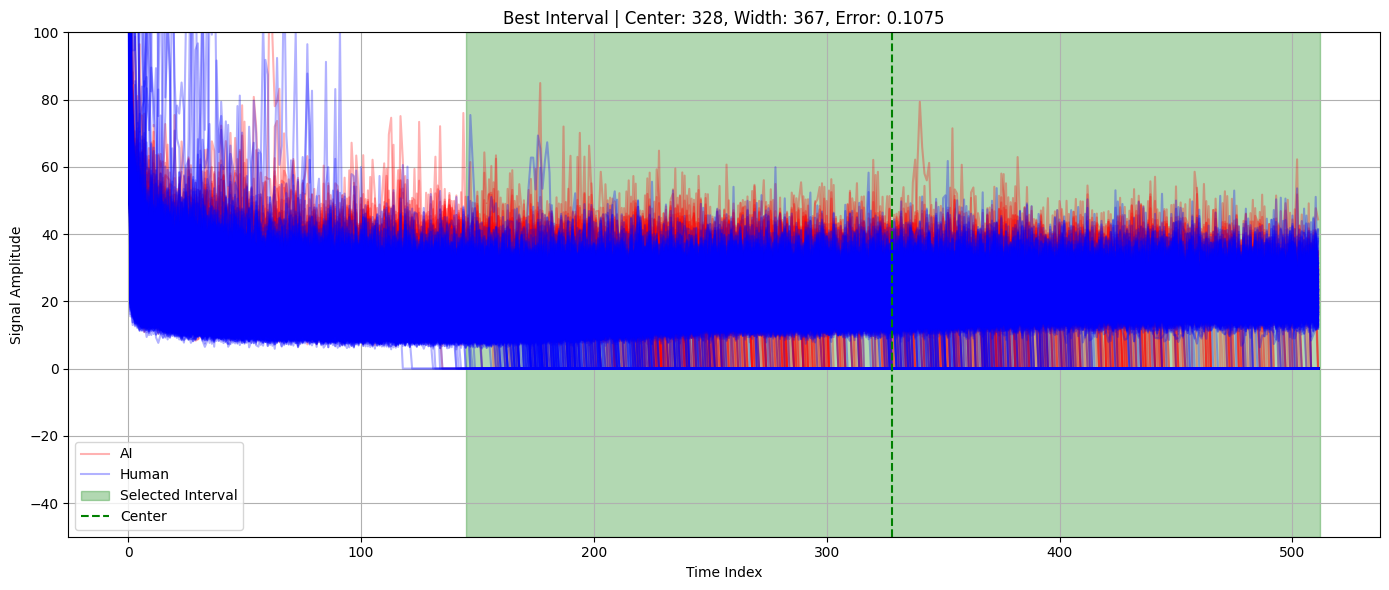

In [24]:
# === Visualise all signals by class with best interval ===

# Indices of each class
sample_0 = np.where(y == 0)[0]
sample_1 = np.where(y == 1)[0]

best_width = best_end - best_start
best_center = best_start + best_width // 2

plt.figure(figsize=(14, 6))

# Plot class 0 signals in red
for i in sample_0:
    plt.plot(x[i], color="red", alpha=0.3, label="AI" if i == sample_0[0] else "")

# Plot class 1 signals in blue
for i in sample_1:
    plt.plot(x[i], color="blue", alpha=0.3, label="Human" if i == sample_1[0] else "")

# Highlight the best interval
plt.axvspan(best_start, best_end, color="green", alpha=0.3, label="Selected Interval")
plt.axvline(best_center, color="green", linestyle="--", label="Center")

plt.title(f"Best Interval | Center: {best_center}, Width: {best_width}, Error: {best_error:.4f}")
plt.xlabel("Time Index")
plt.ylabel("Signal Amplitude")
plt.ylim(-50, 100)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



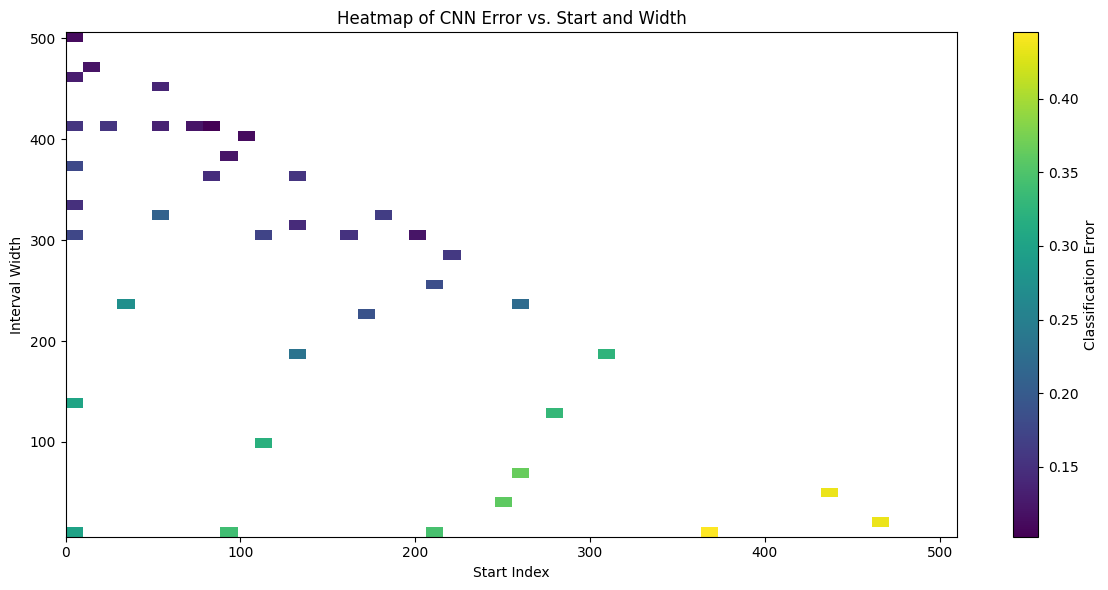

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Assume x_sample and y_sample are defined in the user's environment
# For heatmap: we'll bin widths and compute average error for each bin

x_sample = np.array(x_sample)
y_sample = np.array(y_sample).flatten()
widths = x_sample[:, 1] - x_sample[:, 0]

# Create a 2D histogram heatmap: (start, width) -> error
start_indices = x_sample[:, 0]

# Define grid size
start_bins = np.arange(0, signal_length, 10)
width_bins = np.arange(6, signal_length, 10)

# Prepare 2D array for storing average errors
heatmap = np.full((len(start_bins), len(width_bins)), np.nan)

# Fill heatmap by averaging over matching bins
for (s, e), err in zip(x_sample, y_sample):
    w = e - s
    if w < 6:
        continue
    s_bin = np.searchsorted(start_bins, s, side='right') - 1
    w_bin = np.searchsorted(width_bins, w, side='right') - 1
    if 0 <= s_bin < len(start_bins) and 0 <= w_bin < len(width_bins):
        if np.isnan(heatmap[s_bin, w_bin]):
            heatmap[s_bin, w_bin] = err
        else:
            heatmap[s_bin, w_bin] = (heatmap[s_bin, w_bin] + err) / 2

# Plot heatmap
plt.figure(figsize=(12, 6))
plt.imshow(heatmap.T, origin='lower', aspect='auto',
           extent=[start_bins[0], start_bins[-1], width_bins[0], width_bins[-1]],
           cmap='viridis')
plt.colorbar(label='Classification Error')
plt.xlabel("Start Index")
plt.ylabel("Interval Width")
plt.title("Heatmap of CNN Error vs. Start and Width")
plt.tight_layout()
plt.show()


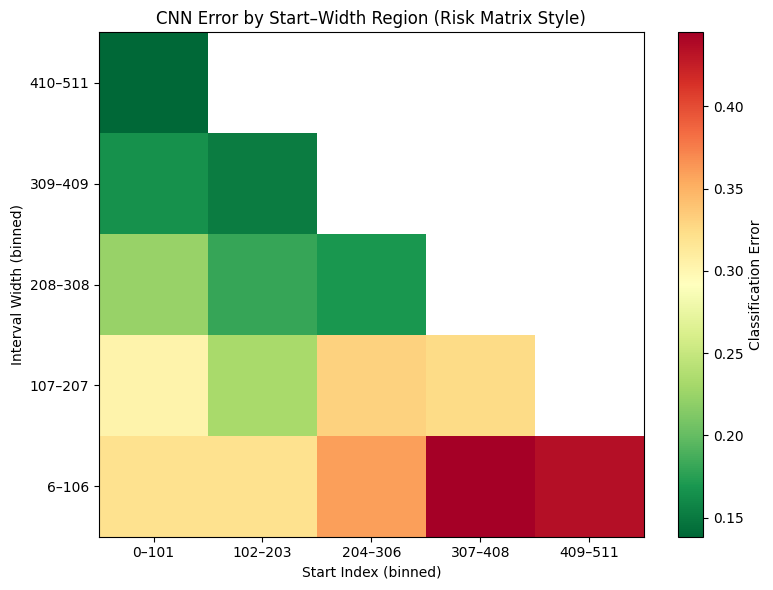

In [51]:
import matplotlib.pyplot as plt
import numpy as np

x_sample = np.array(x_sample)
y_sample = np.array(y_sample).flatten()
widths = x_sample[:, 1] - x_sample[:, 0]
starts = x_sample[:, 0]

# Define bins
start_bins = np.linspace(0, signal_length, 6, dtype=int)  # 5 bins
width_bins = np.linspace(6, signal_length, 6, dtype=int)  # 5 bins

# Create matrix of average errors
heatmap = np.full((len(start_bins) - 1, len(width_bins) - 1), np.nan)

# Fill matrix with mean error
for (s, e), err in zip(x_sample, y_sample):
    w = e - s
    i = np.searchsorted(start_bins, s, side="right") - 1
    j = np.searchsorted(width_bins, w, side="right") - 1
    if 0 <= i < heatmap.shape[0] and 0 <= j < heatmap.shape[1]:
        if np.isnan(heatmap[i, j]):
            heatmap[i, j] = err
        else:
            heatmap[i, j] = (heatmap[i, j] + err) / 2

# Plot the heatmap
fig, ax = plt.subplots(figsize=(8, 6))
c = ax.imshow(
    heatmap.T,
    origin='lower',
    cmap='RdYlGn_r',
    extent=[0, heatmap.shape[0], 0, heatmap.shape[1]],
    aspect='auto'
)

# Overlay points
#for (s, e) in x_sample:
  #  w = e - s
   # i = np.searchsorted(start_bins, s, side="right") - 1
    #j = np.searchsorted(width_bins, w, side="right") - 1
   # if 0 <= i < heatmap.shape[0] and 0 <= j < heatmap.shape[1]:
    #    ax.plot(i + 0.5, j + 0.5, 'ko', markersize=8)

# Set axis ticks to bin labels
ax.set_xticks(np.arange(len(start_bins) - 1) + 0.5)
ax.set_xticklabels([f"{start_bins[i]}–{start_bins[i+1]-1}" for i in range(len(start_bins)-1)])
ax.set_yticks(np.arange(len(width_bins) - 1) + 0.5)
ax.set_yticklabels([f"{width_bins[i]}–{width_bins[i+1]-1}" for i in range(len(width_bins)-1)])
ax.set_xlabel("Start Index (binned)")
ax.set_ylabel("Interval Width (binned)")
ax.set_title("CNN Error by Start–Width Region (Risk Matrix Style)")
fig.colorbar(c, label="Classification Error")
plt.grid(False)
plt.tight_layout()
plt.show()


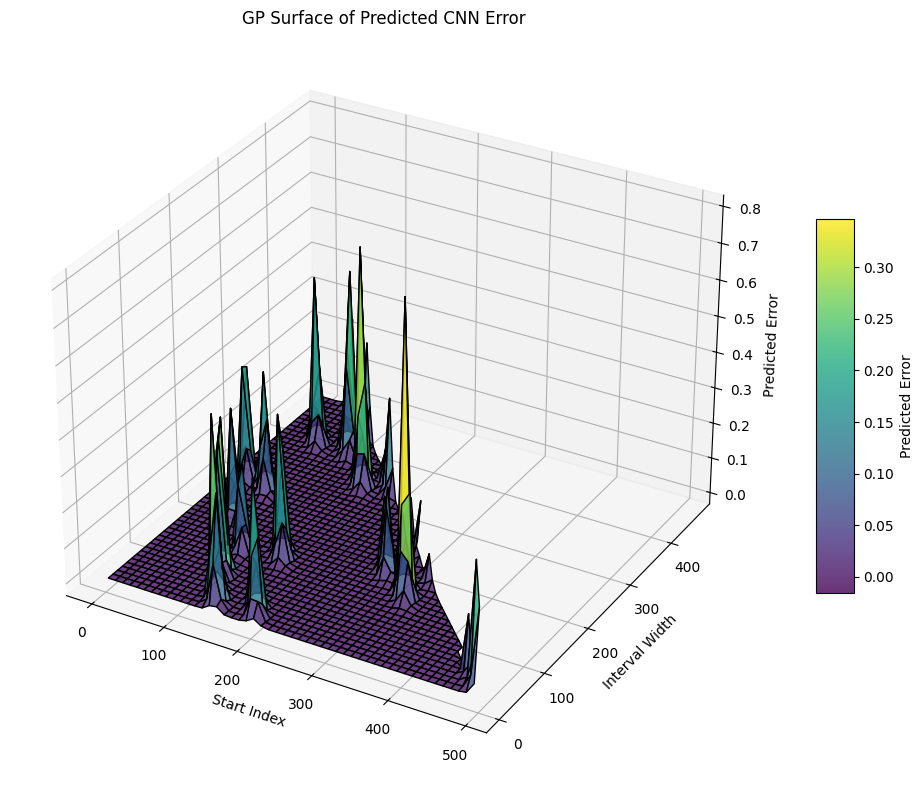

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Ensure x_sample and y_sample are defined
x_sample = np.array(x_sample)
y_sample = np.array(y_sample).flatten()

# Compute widths
start = x_sample[:, 0]
width = x_sample[:, 1] - x_sample[:, 0]

# Create 3D surface grid for plotting
grid_size = 50
start_grid = np.linspace(0, np.max(start), grid_size)
width_grid = np.linspace(6, np.max(width), grid_size)
Start, Width = np.meshgrid(start_grid, width_grid)
grid_points = np.vstack([Start.ravel(), Width.ravel()]).T

# Convert grid to (start, end) format for GP
End = grid_points[:, 0] + grid_points[:, 1]
valid = (End <= signal_length)
valid_grid = grid_points[valid]
valid_end = End[valid].reshape(-1, 1)
valid_start = valid_grid[:, 0].reshape(-1, 1)
X_pred = np.hstack([valid_start, valid_end])
Z = np.full(Start.shape, np.nan)

# Predict using GP
mu = gp.predict(X_pred)
Z_flat = np.full(grid_points.shape[0], np.nan)
Z_flat[valid] = mu
Z = Z_flat.reshape(Start.shape)

# 3D surface plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(Start, Width, Z, cmap='viridis', edgecolor='k', alpha=0.8)
ax.set_xlabel("Start Index")
ax.set_ylabel("Interval Width")
ax.set_zlabel("Predicted Error")
ax.set_title("GP Surface of Predicted CNN Error")
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label="Predicted Error")
plt.tight_layout()
plt.show()


In [ ]:
# Load the genetic data files
actual_path = "actual.csv"
train_genetic_path = "data_set_ALL_AML_train.csv"
test_genetic_path = "data_set_ALL_AML_independent.csv"

# Load the files
actual_df = pd.read_csv(actual_path)
train_genetic_df = pd.read_csv(train_genetic_path)
test_genetic_df = pd.read_csv(test_genetic_path)

# Show a few rows of each
actual_df.head(), train_genetic_df.head(), test_genetic_df.head()


(   patient cancer
 0        1    ALL
 1        2    ALL
 2        3    ALL
 3        4    ALL
 4        5    ALL,
                       Gene Description Gene Accession Number    1 call    2  \
 0  AFFX-BioB-5_at (endogenous control)        AFFX-BioB-5_at -214    A -139   
 1  AFFX-BioB-M_at (endogenous control)        AFFX-BioB-M_at -153    A  -73   
 2  AFFX-BioB-3_at (endogenous control)        AFFX-BioB-3_at  -58    A   -1   
 3  AFFX-BioC-5_at (endogenous control)        AFFX-BioC-5_at   88    A  283   
 4  AFFX-BioC-3_at (endogenous control)        AFFX-BioC-3_at -295    A -264   
 
   call.1    3 call.2    4 call.3  ...   29 call.33   30 call.34   31 call.35  \
 0      A  -76      A -135      A  ...   15       A -318       A  -32       A   
 1      A  -49      A -114      A  ... -114       A -192       A  -49       A   
 2      A -307      A  265      A  ...    2       A  -95       A   49       A   
 3      A  309      A   12      A  ...  193       A  312       A  230       P  

Best center:         326
Best width:          373
Best interval start: 139
Best interval end:   512
Best interval error: 0.1
Full model error:    0.115


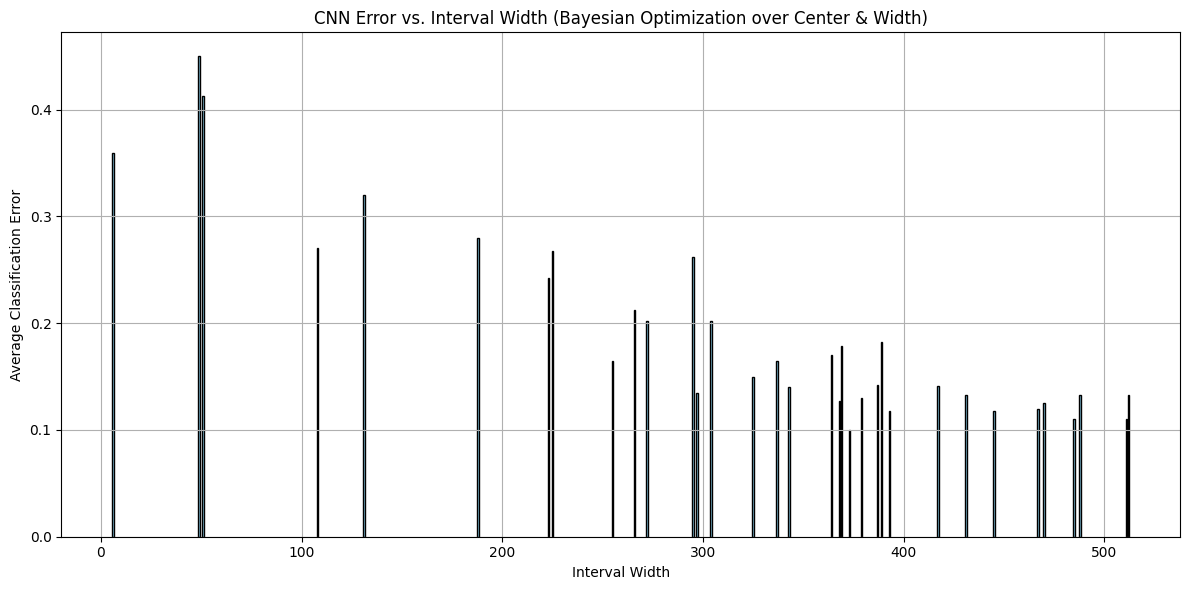

In [ ]:
#import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# === Load and preprocess data ===
with open("data (1).pkl", "rb") as f:
    data = pickle.load(f)

x = np.array(data['x'])
y = np.array(data['y'])[:x.shape[0]]
signal_length = x.shape[1]
min_width = 6

# === CNN Definition ===
class CNN1D(nn.Module):
    def __init__(self, input_length, laten=10):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, laten, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(laten, laten, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        self.flatten = nn.Flatten()
        conv_output_length = self._get_conv_output_shape(input_length)
        self.fc1 = nn.Linear(conv_output_length, laten)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(laten, 1)
        self.sigmoid = nn.Sigmoid()

    def _get_conv_output_shape(self, input_length):
        dummy_input = torch.zeros(1, 1, input_length)
        x = self.pool1(torch.relu(self.conv1(dummy_input)))
        x = self.pool2(torch.relu(self.conv2(x)))
        return x.view(1, -1).size(1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.sigmoid(self.fc2(x))

# === Train CNN on interval [start:end] ===
def train_nn(data, labels, start, end):
    if end - start < min_width:
        return 1.0
    x_interval = data[:, start:end]
    y_binary = labels.astype(np.float32).reshape(-1, 1)
    scaler = StandardScaler().fit(x_interval)
    x_scaled = scaler.transform(x_interval)[:, :, np.newaxis]
    x_train, x_test, y_train, y_test = train_test_split(
        x_scaled, y_binary, stratify=y_binary, test_size=0.2, random_state=42
    )
    x_train = torch.tensor(x_train).float()
    x_test = torch.tensor(x_test).float()
    y_train = torch.tensor(y_train).float()
    y_test = torch.tensor(y_test).float()
    model = CNN1D(input_length=x_train.shape[1])
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)
    model.train()
    for epoch in range(10):
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
    model.eval()
    with torch.no_grad():
        preds = model(x_test).numpy()
        y_pred = (preds > 0.5).astype(int)
    return 1 - accuracy_score(y_test.numpy(), y_pred)

# === Expected Improvement ===
def expected_improvement(X, X_sample, Y_sample, model, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    mu_sample_opt = np.min(Y_sample)
    with np.errstate(divide='warn'):
        imp = mu_sample_opt - mu - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# === BO in (start, end) triangle domain ===
n_initial = 10
evaluated_intervals = set()
initial_samples = []
rng = np.random.default_rng(42)

while len(initial_samples) < n_initial:
    s = rng.integers(0, signal_length - min_width)
    e = rng.integers(s + min_width, signal_length + 1)
    if (s, e) not in evaluated_intervals:
        initial_samples.append([s, e])
        evaluated_intervals.add((s, e))

X_sample = np.array(initial_samples, dtype=int)
Y_sample = np.array([train_nn(x, y, s, e) for s, e in X_sample]).reshape(-1, 1)

# Fit GP and iterate
kernel = Matern(length_scale=(10.0, 10.0), length_scale_bounds=(1e-2, 1e3), nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10, normalize_y=True)

max_iter = 30
for _ in range(max_iter):
    gp.fit(X_sample, Y_sample)
    candidates = [
        [s, e] for s in range(0, signal_length - min_width)
        for e in range(s + min_width, signal_length + 1)
        if (s, e) not in evaluated_intervals
    ]
    if not candidates:
        break
    candidate_grid = np.array(candidates, dtype=int)
    ei = expected_improvement(candidate_grid, X_sample, Y_sample, gp)
    best_idx = int(np.argmax(ei))
    next_s, next_e = candidate_grid[best_idx]
    new_error = train_nn(x, y, next_s, next_e)
    X_sample = np.vstack((X_sample, [[next_s, next_e]]))
    Y_sample = np.append(Y_sample, [[new_error]])
    evaluated_intervals.add((next_s, next_e))

# === Report best interval ===
best_idx = int(np.argmin(Y_sample))
best_start, best_end = X_sample[best_idx]
best_error = float(Y_sample[best_idx])
full_model_error = train_nn(x, y, 0, signal_length)

print("Best interval start:", best_start)
print("Best interval end:  ", best_end)
print("Best width:         ", best_end - best_start)
print("Best interval error:", round(best_error, 4))
print("Full model error:   ", round(full_model_error, 4))



In [63]:
# %% ---------------------- imports & seeds ----------------------
import os
import math
import random
import numpy as np
import torch
import torch.nn as nn
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from scipy.stats import norm

train_data=np.loadtxt("ECG200_TRAIN.txt")
test_data=np.loadtxt("ECG200_TEST.txt")

# %% ---------------------- model ----------------------
class TFInspiredCNN(nn.Module):
    """
    Two conv+pool blocks with padding (length-preserving for stride=1),
    then dynamic flatten to a small MLP head.
    """
    def __init__(self, in_length, n_classes=2):
        super().__init__()
        # padding makes conv length-preserving for stride=1
        self.conv1 = nn.Conv1d(1, 16, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()

        # dynamically compute flattened dim
        with torch.no_grad():
            _x = torch.zeros(1, 1, in_length)
            _x = self.pool1(torch.relu(self.conv1(_x)))
            _x = self.pool2(torch.relu(self.conv2(_x)))
            flat_dim = _x.numel()

        self.fc1 = nn.Linear(flat_dim, 64)
        self.fc2 = nn.Linear(64, n_classes)

    def forward(self, x):
        # x: [B, L]
        x = x.unsqueeze(1)  # [B, 1, L]
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# %% ---------------------- windowing utils ----------------------
MIN_WIN = 16  # safe min length for two pools; adjust if you change pooling

def clamp_window(center, width, L):
    """
    Given (center, width) and total series length L, return (start, end) indices
    for a fixed-length window that stays in-bounds. Ensures width >= MIN_WIN.
    """
    width = int(max(MIN_WIN, min(int(width), L)))
    center = int(np.clip(int(center), 0, L - 1))

    start = center - width // 2
    end = start + width
    if start < 0:
        start, end = 0, width
    if end > L:
        end, start = L, L - width
    return start, end, width

# %% ---------------------- training helper ----------------------
def train_nn(
    X_train, y_train, X_test, y_test,
    center, width,
    epochs=10, batch_size=32, lr=1e-3, seed=0
):
    torch.manual_seed(seed)
    L = X_train.shape[1]

    # crop window
    start, end, width = clamp_window(center, width, L)
    Xtr = X_train[:, start:end]
    Xte = X_test[:, start:end]

    # model sized to this exact input length
    model = TFInspiredCNN(in_length=width, n_classes=int(np.unique(y_train).size))
    model.train()

    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(y_train, dtype=torch.long)

    ds = torch.utils.data.TensorDataset(Xtr_t, ytr_t)
    dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        for bx, by in dl:
            optimizer.zero_grad()
            out = model(bx)
            loss = criterion(out, by)
            loss.backward()
            optimizer.step()

    # eval on test set crop
    model.eval()
    with torch.no_grad():
        Xte_t = torch.tensor(Xte, dtype=torch.float32)
        logits = model(Xte_t)
        preds = logits.argmax(dim=1).cpu().numpy()
    err = float((preds != y_test).mean())
    return err

# %% ---------------------- BO utilities (EI) ----------------------
def expected_improvement(X, model, y_best, xi=0.01):
    """
    X: (m, d) candidates
    model: sklearn GP
    y_best: best observed objective (we minimize error)
    """
    mu, sigma = model.predict(X, return_std=True)
    sigma = np.clip(sigma, 1e-12, None)
    # since we minimize, improvement is y_best - y
    imp = y_best - mu - xi
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    return np.maximum(ei, 0.0)

def propose_location(bounds, gp, y_best, n_samp=2000):
    """
    Random-search maximization of EI over bounds.
    bounds: [(low0, high0), (low1, high1)]
    """
    X0 = np.random.uniform(bounds[0][0], bounds[0][1], size=n_samp)
    X1 = np.random.uniform(bounds[1][0], bounds[1][1], size=n_samp)
    Xcand = np.stack([X0, X1], axis=1)
    ei = expected_improvement(Xcand, gp, y_best)
    idx = int(np.argmax(ei))
    return Xcand[idx:idx+1]

# %% ---------------------- Run BO over (center, width) ----------------------
# Bounds: center in [0, L-1], width in [MIN_WIN, L]
BO_BOUNDS = [(0.0, float(L - 1)), (float(MIN_WIN), float(L))]

# Initial design
n_init = 8
X_init = np.zeros((n_init, 2), dtype=np.float64)
X_init[:, 0] = np.random.uniform(0, L - 1, size=n_init)        # center
X_init[:, 1] = np.random.uniform(MIN_WIN, L, size=n_init)      # width

# Evaluate initial design
Y_init = []
for c, w in X_init:
    err = train_nn(
        X_train_full, y_train_full, X_test_full, y_test_full,
        center=int(c), width=int(w),
        epochs=10, batch_size=32, lr=1e-3, seed=SEED
    )
    Y_init.append(err)

X_sample = X_init.astype(np.float64)
Y_sample = np.array(Y_init, dtype=np.float64)

# GP model for BO (Matérn 5/2 + noise)
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-3))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3, normalize_y=True, random_state=SEED)

n_iter = 20  # BO steps
for it in range(n_iter):
    gp.fit(X_sample, Y_sample)
    y_best = np.min(Y_sample)
    x_next = propose_location(BO_BOUNDS, gp, y_best, n_samp=4000)

    # round to ints for training
    c_next, w_next = int(round(x_next[0, 0])), int(round(x_next[0, 1]))

    y_next = train_nn(
        X_train_full, y_train_full, X_test_full, y_test_full,
        center=c_next, width=w_next,
        epochs=10, batch_size=32, lr=1e-3, seed=SEED
    )

    X_sample = np.vstack([X_sample, x_next])
    Y_sample = np.append(Y_sample, y_next)

    print(f"[{it+1:02d}/{n_iter}] center={c_next:3d}, width={w_next:3d} -> test error={y_next:.3f} | best={np.min(Y_sample):.3f}")

best_idx = int(np.argmin(Y_sample))
best_c, best_w = X_sample[best_idx]
best_err = float(np.min(Y_sample))
print("\nBest found:")
print(f"  center={int(round(best_c))}, width={int(round(best_w))}, test error={best_err:.4f}")


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[01/20] center= 31, width= 70 -> test error=0.230 | best=0.190
[02/20] center= 26, width= 93 -> test error=0.200 | best=0.190


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[03/20] center= 52, width= 76 -> test error=0.200 | best=0.190
[04/20] center= 34, width= 53 -> test error=0.190 | best=0.190


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


...

[13/20] center= 94, width= 27 -> test error=0.280 | best=0.190
[14/20] center= 93, width= 57 -> test error=0.230 | best=0.190


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[15/20] center=  9, width= 95 -> test error=0.210 | best=0.190
[16/20] center= 88, width= 93 -> test error=0.230 | best=0.190


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[17/20] center= 49, width= 18 -> test error=0.230 | best=0.190
[18/20] center= 32, width= 54 -> test error=0.200 | best=0.190
[19/20] center= 33, width= 37 -> test error=0.230 | best=0.190
[20/20] center= 36, width= 34 -> test error=0.180 | best=0.180

Best found:
  center=36, width=34, test error=0.1800


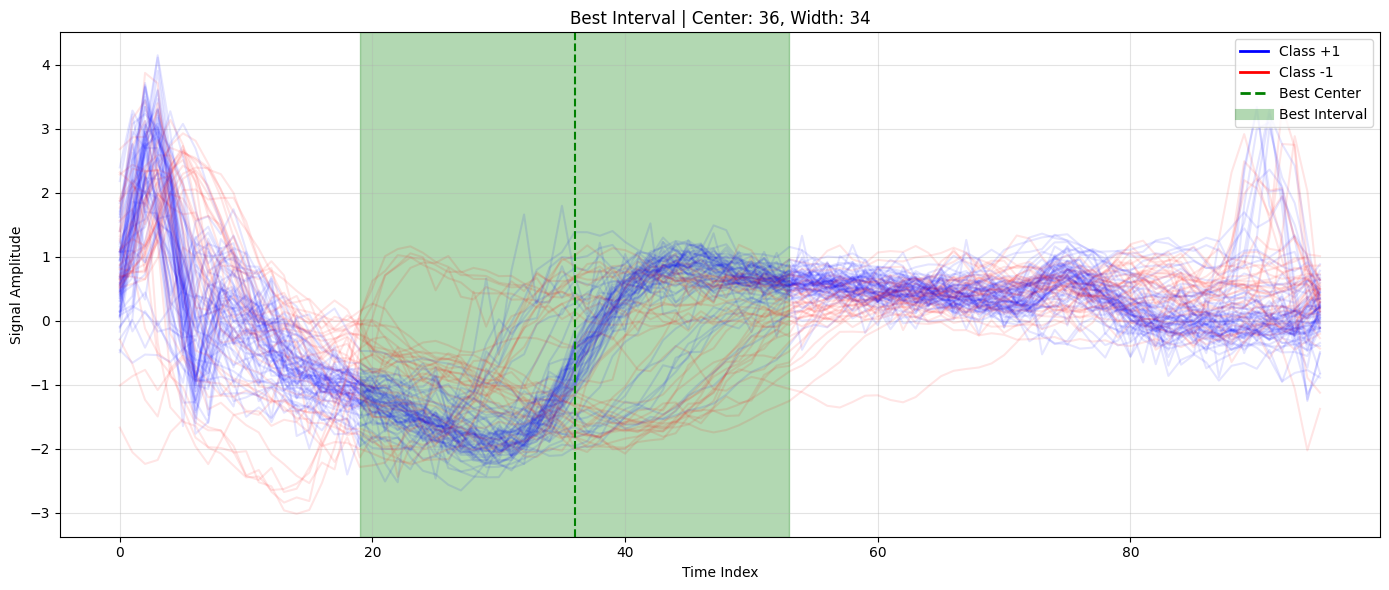

In [68]:
# --- multi-trace overlay with best interval (no averaging) ---
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# If you already have clamp_window, this guard will skip redefining it
if 'clamp_window' not in globals():
    def clamp_window(center, width, L):
        half = max(1, int(width) // 2)
        start = max(0, min(int(center) - half, L - int(width)))
        end = start + int(width)
        return start, end, end - start

# pick which split to visualize
# (change to X_train_full / y_train_full if you want the training set)
features = X_test_full
# ensure labels are in {-1, +1} so the color check works
labels = np.where(y_test_full > 0, 1, -1)

# convert your best params -> concrete window indices
L = features.shape[1]
best_center = int(round(best_c))   # or best_center if you already have it
best_width  = int(round(best_w))   # or best_width  if you already have it
best_start, best_end, best_width = clamp_window(best_center, best_width, L)

plt.figure(figsize=(14, 6))

for i in range(features.shape[0]):
    color = "blue" if labels[i] == 1 else "red"
    plt.plot(features[i], color=color, alpha=0.1)

# overlay the best interval + center
plt.axvspan(best_start, best_end, color="green", alpha=0.3, label="Best Interval")
plt.axvline(best_center, color="green", linestyle="--", label="Best Center")

# cleaner legend with class colors
legend_elems = [
    Line2D([0],[0], color='blue', lw=2, label='Class +1'),
    Line2D([0],[0], color='red',  lw=2, label='Class -1'),
    Line2D([0],[0], color='green', lw=2, linestyle='--', label='Best Center'),
    Line2D([0],[0], color='green', lw=8, alpha=0.3, label='Best Interval'),
]

title = f"Best Interval | Center: {best_center}, Width: {best_width}"


plt.title(title)
plt.xlabel("Time Index")
plt.ylabel("Signal Amplitude")
plt.legend(handles=legend_elems, loc='upper right')
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()


In [83]:
# Re-run everything after kernel reset
import numpy as np
import torch
import torch.nn as nn
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from scipy.stats import norm
import matplotlib.pyplot as plt

# Load data
train_data = np.loadtxt("ECG200_TRAIN.txt")
test_data = np.loadtxt("ECG200_TEST.txt")
X_train_full = np.vstack([train_data[:, 1:], test_data[:, 1:]]).astype(np.float32)
y_train_full = np.concatenate([train_data[:, 0], test_data[:, 0]]).astype(int)
X_test_full, y_test_full = X_train_full, y_train_full

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

L = X_train_full.shape[1]
MIN_WIN = 16

class TFInspiredCNN(nn.Module):
    def __init__(self, in_length, n_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        with torch.no_grad():
            _x = torch.zeros(1, 1, in_length)
            _x = self.pool1(torch.relu(self.conv1(_x)))
            _x = self.pool2(torch.relu(self.conv2(_x)))
            flat_dim = _x.numel()
        self.fc1 = nn.Linear(flat_dim, 64)
        self.fc2 = nn.Linear(64, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

def train_nn(X_train, y_train, X_test, y_test, start, end, epochs=10, batch_size=32, lr=1e-3, seed=0):
    torch.manual_seed(seed)
    Xtr = X_train[:, start:end]
    Xte = X_test[:, start:end]
    model = TFInspiredCNN(in_length=Xtr.shape[1], n_classes=int(np.unique(y_train).size))
    model.train()
    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(y_train, dtype=torch.long)
    ds = torch.utils.data.TensorDataset(Xtr_t, ytr_t)
    dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    for _ in range(epochs):
        for bx, by in dl:
            optimizer.zero_grad()
            out = model(bx)
            loss = criterion(out, by)
            loss.backward()
            optimizer.step()
    model.eval()
    with torch.no_grad():
        Xte_t = torch.tensor(Xte, dtype=torch.float32)
        logits = model(Xte_t)
        preds = logits.argmax(dim=1).cpu().numpy()
    return float((preds != y_test).mean())

def expected_improvement(X, model, y_best, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    sigma = np.clip(sigma, 1e-12, None)
    imp = y_best - mu - xi
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    return np.maximum(ei, 0.0)

# BO loop in (start, end)
n_init = 8
evaluated_intervals = set()
initial_samples = []
rng = np.random.default_rng(SEED)

while len(initial_samples) < n_init:
    s = rng.integers(0, L - MIN_WIN)
    e = rng.integers(s + MIN_WIN, L + 1)
    if (s, e) not in evaluated_intervals:
        initial_samples.append([s, e])
        evaluated_intervals.add((s, e))

X_sample = np.array(initial_samples, dtype=int)
Y_sample = np.array([train_nn(X_train_full, y_train_full, X_test_full, y_test_full, s, e) for s, e in X_sample]).reshape(-1, 1)

kernel = ConstantKernel(1.0) * Matern(nu=2.5) + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3, normalize_y=True, random_state=SEED)

n_iter = 20
for it in range(n_iter):
    gp.fit(X_sample, Y_sample)
    candidates = [[s, e] for s in range(0, L - MIN_WIN) for e in range(s + MIN_WIN, L + 1) if (s, e) not in evaluated_intervals]
    if not candidates:
        break
    candidate_grid = np.array(candidates, dtype=int)
    ei = expected_improvement(candidate_grid, gp, np.min(Y_sample))
    best_idx = int(np.argmax(ei))
    next_s, next_e = candidate_grid[best_idx]
    y_next = train_nn(X_train_full, y_train_full, X_test_full, y_test_full, next_s, next_e)
    X_sample = np.vstack([X_sample, [[next_s, next_e]]])
    Y_sample = np.append(Y_sample, y_next)
    evaluated_intervals.add((next_s, next_e))

best_idx = int(np.argmin(Y_sample))
best_s, best_e = X_sample[best_idx]
best_err = float(np.min(Y_sample))

(best_s, best_e, best_err)


IndexError: Target -1 is out of bounds.

In [5]:
# Imports
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import pandas as pd
import random
import os

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# Limit threads to keep things snappy
torch.set_num_threads(1)

# ---------- Load ECG200 data ----------
train_path = "ECG200_TRAIN.txt"
test_path = "ECG200_TEST.txt"

train = np.loadtxt(train_path)
test = np.loadtxt(test_path)

y_train = train[:, 0]
X_train = train[:, 1:]
y_test = test[:, 0]
X_test = test[:, 1:]

# Map labels from {-1, 1} -> {0, 1}
y_train = ((y_train + 1) / 2).astype(int)
y_test = ((y_test + 1) / 2).astype(int)

n_train, T = X_train.shape

# Per-sample standardisation helper
def zscore_per_sample(X):
    Xc = X - X.mean(axis=1, keepdims=True)
    Xs = Xc / (Xc.std(axis=1, keepdims=True) + 1e-8)
    return Xs

# ---------- CNN definition (from user) ----------
class CNN1D(nn.Module):
    def __init__(self, input_length, laten=10):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, laten, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(laten, laten, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool1d(2)
        self.flatten = nn.Flatten()
        conv_output_length = self._get_conv_output_shape(input_length)
        self.fc1 = nn.Linear(conv_output_length, laten)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(laten, 1)

    def _get_conv_output_shape(self, input_length):
        dummy_input = torch.zeros(1, 1, input_length)
        x = self.pool1(torch.relu(self.conv1(dummy_input)))
        x = self.pool2(torch.relu(self.conv2(x)))
        return x.view(1, -1).size(1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

# Helper to extract latent features (output of ReLU(fc1)) for LR
def extract_features(model, X_tensor, batch_size=64):
    model.eval()
    feats = []
    with torch.no_grad():
        dl = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=False)
        for (xb,) in dl:
            x = xb.permute(0, 2, 1)
            x = model.pool1(F.relu(model.conv1(x)))
            x = model.pool2(F.relu(model.conv2(x)))
            x = model.flatten(x)
            x = F.relu(model.fc1(x))
            feats.append(x.cpu().numpy())
    return np.vstack(feats)

# Train a small CNN quickly
def train_cnn(X_tr, y_tr, X_te, y_te, input_length, epochs=8, batch_size=32, lr=1e-3):
    device = torch.device("cpu")
    model = CNN1D(input_length=input_length, laten=10).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    Xtr_t = torch.tensor(X_tr, dtype=torch.float32).unsqueeze(-1)
    Xte_t = torch.tensor(X_te, dtype=torch.float32).unsqueeze(-1)
    ytr_t = torch.tensor(y_tr.reshape(-1, 1), dtype=torch.float32)
    yte_t = torch.tensor(y_te.reshape(-1, 1), dtype=torch.float32)

    train_ds = TensorDataset(Xtr_t, ytr_t)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    model.train()
    for ep in range(epochs):
        for xb, yb in train_dl:
            opt.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            opt.step()

    # Evaluate CNN-only accuracy on test
    model.eval()
    with torch.no_grad():
        logits_te = model(Xte_t).squeeze(1).numpy()
        preds_cnn = (1 / (1 + np.exp(-logits_te)) > 0.5).astype(int)
        acc_cnn = accuracy_score(y_te, preds_cnn)

    return model, acc_cnn

# ---------- Full-signal CNN error ----------
X_train_full = zscore_per_sample(X_train)
X_test_full = zscore_per_sample(X_test)

full_model, full_acc = train_cnn(X_train_full, y_train, X_test_full, y_test, input_length=T, epochs=12)
full_error_rate = 1 - full_acc

# ---------- Interval search with Logistic Regression on CNN features ----------
interval_len = 20
best = {"start": None, "end": None, "error": 1.0}

records = []

# We use a small number of epochs to keep the runtime reasonable while scanning all intervals.
for start in range(0, T - interval_len + 1):
    end = start + interval_len

    # Slice interval and standardise per-sample
    Xtr_slice = zscore_per_sample(X_train[:, start:end])
    Xte_slice = zscore_per_sample(X_test[:, start:end])

    # Train CNN on this interval (few epochs)
    model, _ = train_cnn(Xtr_slice, y_train, Xte_slice, y_test, input_length=interval_len, epochs=8)

    # Extract latent features and fit LR
    Xtr_t = torch.tensor(Xtr_slice, dtype=torch.float32).unsqueeze(-1)
    Xte_t = torch.tensor(Xte_slice, dtype=torch.float32).unsqueeze(-1)

    Z_train = extract_features(model, Xtr_t)  # shape (n_train, laten)
    Z_test = extract_features(model, Xte_t)

    # Scale features and fit logistic regression
    scaler = StandardScaler()
    Ztr_s = scaler.fit_transform(Z_train)
    Zte_s = scaler.transform(Z_test)

    lr = LogisticRegression(max_iter=1000, solver="lbfgs")
    lr.fit(Ztr_s, y_train)
    y_pred = lr.predict(Zte_s)
    acc = accuracy_score(y_test, y_pred)
    err = 1 - acc

    records.append({"start": start, "end": end, "error_rate": err})

    if err < best["error"]:
        best.update({"start": start, "end": end, "error": err})


best, full_error_rate


({'start': 64, 'end': 84, 'error': 0.15000000000000002}, 0.21999999999999997)

In [13]:
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import pandas as pd
import random
from sklearn.model_selection import train_test_split

# --------------------
# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.set_num_threads(1)

# --------------------
# Load pickle
with open("data (1).pkl", "rb") as f:
    data = pickle.load(f)

x = np.array(data['x'])
y = np.array(data['y'])
y = y[:x.shape[0]]  # Trim in case of mismatch

# Ensure labels are integers 0/1
y = np.array(y).astype(int)

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=seed, stratify=y
)

n_train, T = X_train.shape

# --------------------
# Per-sample z-score
def zscore_per_sample(X):
    Xc = X - X.mean(axis=1, keepdims=True)
    Xs = Xc / (Xc.std(axis=1, keepdims=True) + 1e-8)
    return Xs

# --------------------
# CNN class
class CNN1D(nn.Module):
    def __init__(self, input_length, laten=10):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, laten, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(laten, laten, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool1d(2)
        self.flatten = nn.Flatten()
        conv_output_length = self._get_conv_output_shape(input_length)
        self.fc1 = nn.Linear(conv_output_length, laten)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(laten, 1)

    def _get_conv_output_shape(self, input_length):
        dummy_input = torch.zeros(1, 1, input_length)
        x = self.pool1(torch.relu(self.conv1(dummy_input)))
        x = self.pool2(torch.relu(self.conv2(x)))
        return x.view(1, -1).size(1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

# --------------------
# Feature extraction
def extract_features(model, X_tensor, batch_size=64):
    model.eval()
    feats = []
    with torch.no_grad():
        dl = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=False)
        for (xb,) in dl:
            x = xb.permute(0, 2, 1)
            x = model.pool1(F.relu(model.conv1(x)))
            x = model.pool2(F.relu(model.conv2(x)))
            x = model.flatten(x)
            x = F.relu(model.fc1(x))
            feats.append(x.cpu().numpy())
    return np.vstack(feats)

# --------------------
# Train CNN
def train_cnn(X_tr, y_tr, X_te, y_te, input_length, epochs=8, batch_size=32, lr=1e-3):
    device = torch.device("cpu")
    model = CNN1D(input_length=input_length, laten=10).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    Xtr_t = torch.tensor(X_tr, dtype=torch.float32).unsqueeze(-1)
    Xte_t = torch.tensor(X_te, dtype=torch.float32).unsqueeze(-1)
    ytr_t = torch.tensor(y_tr.reshape(-1, 1), dtype=torch.float32)
    yte_t = torch.tensor(y_te.reshape(-1, 1), dtype=torch.float32)

    train_ds = TensorDataset(Xtr_t, ytr_t)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    for ep in range(epochs):
        model.train()
        for xb, yb in train_dl:
            opt.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            opt.step()

    # CNN-only accuracy
    model.eval()
    with torch.no_grad():
        logits_te = model(Xte_t).squeeze(1).numpy()
        preds_cnn = (1 / (1 + np.exp(-logits_te)) > 0.5).astype(int)
        acc_cnn = accuracy_score(y_te, preds_cnn)

    return model, acc_cnn

# --------------------
# Full-signal CNN
X_train_full = zscore_per_sample(X_train)
X_test_full = zscore_per_sample(X_test)
full_model, full_acc = train_cnn(X_train_full, y_train, X_test_full, y_test, input_length=T, epochs=12)
full_error_rate = 1 - full_acc

# --------------------
# Interval sweep
interval_len = 20
best = {"start": None, "end": None, "error": 1.0}
records = []

for start in range(0, T - interval_len + 1):
    end = start + interval_len
    Xtr_slice = zscore_per_sample(X_train[:, start:end])
    Xte_slice = zscore_per_sample(X_test[:, start:end])

    model, _ = train_cnn(Xtr_slice, y_train, Xte_slice, y_test, input_length=interval_len, epochs=8)

    Xtr_t = torch.tensor(Xtr_slice, dtype=torch.float32).unsqueeze(-1)
    Xte_t = torch.tensor(Xte_slice, dtype=torch.float32).unsqueeze(-1)
    Z_train = extract_features(model, Xtr_t)
    Z_test = extract_features(model, Xte_t)

    scaler = StandardScaler()
    Ztr_s = scaler.fit_transform(Z_train)
    Zte_s = scaler.transform(Z_test)

    lr = LogisticRegression(max_iter=1000, solver="lbfgs")
    lr.fit(Ztr_s, y_train)
    y_pred = lr.predict(Zte_s)
    err = 1 - accuracy_score(y_test, y_pred)

    records.append({"start": start, "end": end, "error_rate": err})

    if err < best["error"]:
        best.update({"start": start, "end": end, "error": err})

# --------------------
# Save results
pd.DataFrame(records).to_csv("interval_search_results.csv", index=False)

print(f"Best interval: ({best['start']}, {best['end']}) with error {best['error']:.3f}")
print(f"Full-signal CNN error rate: {full_error_rate:.3f}")
print("Results saved to interval_search_results.csv")


Best interval: (216, 236) with error 0.318
Full-signal CNN error rate: 0.228
Results saved to interval_search_results.csv
